# Clasificación de personajes de los Simpsons

## Introducción
El objetivo de este proyecto es construir un modelo de Deep Learning basado en Redes Neuronales Convolucionales (CNN) capaz de clasificar imágenes de los personajes de la famosa serie animada *Los Simpsons*. El dataset proporcionado presenta varios retos intrínsecos de la visión computacional en el mundo real, tales como desbalance severo de clases y variaciones en la iluminación, poses y fondos de las imágenes.

## Inicialización y Entorno

Para el desarrollo de esta solución, hemos seleccionado el siguiente Stack Tecnológico:
- **PyTorch & PyTorch Lightning**: Frameworks principales para la definición y entrenamiento de la arquitectura neuronal. Lightning nos permite estructurar el código de manera limpia, evitando el boilerplate del bucle de entrenamiento.
- **Torchvision**: Para la carga eficiente de las imágenes y la aplicación de preprocesamiento y aumentación nativa.
- **TorchMetrics, TorchInfo**: Para evaluación estandarizada (Accuracy, F1, Precision, Recall) y visualización del resumen de parámetros de las redes.
- **Optuna**: Para la búsqueda automatizada y optimización de hiperparámetros.
- **Grad-CAM**: Para la interpretabilidad visual (mapas de calor) de las predicciones de la red neuronal.

In [19]:
import sys
import os
sys.path.append(os.path.abspath('..'))

from dataclasses import dataclass
import collections

import torch
import torch.nn as nn
import torchvision.models as models
import lightning as L
from lightning.pytorch.callbacks import ModelCheckpoint, EarlyStopping
from torchinfo import summary
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import optuna

from src.data import SimpsonsDataModule
from src.lightning_module import SimpsonsModule

L.seed_everything(42, workers=True)
torch.set_float32_matmul_precision('medium')

# Configuracion de estilo global
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 6)

print(f"PyTorch: {torch.__version__}")
print(f"Device: {'cuda' if torch.cuda.is_available() else 'cpu'}")

class MemoryHistoryCallback(L.Callback):
    def __init__(self):
        super().__init__()
        self.history = []
    def on_validation_epoch_end(self, trainer, pl_module):
        if not trainer.sanity_checking:
            metrics = {k: v.item() for k, v in trainer.callback_metrics.items()}
            metrics['epoch'] = trainer.current_epoch
            self.history.append(metrics)


Seed set to 42


PyTorch: 2.5.1+cu121
Device: cuda


## Carga de Datos y Preprocesamiento
A continuación, definimos nuestra clase `Config` que encapsula los hiperparámetros globales. Luego inicializamos el `SimpsonsDataModule`, el cual se encarga de:
1. Extraer los datos.
2. Escanear y mapear las clases.
3. Crear el set de entrenamiento, validación (split 80/20) y prueba.
4. Aplicar transformaciones (`Resize`, `Normalize`) mediante `torchvision.transforms.v2`.

In [20]:
@dataclass
class Config:
    in_channels: int = 3
    num_classes: int = 42
    image_size: int = 128
    batch_size: int = 32
    lr: float = 1e-3
    weight_decay: float = 1e-4
    max_epochs: int = 5 
    data_dir: str = "../data"

cfg = Config()

# Inicializar Data Module y preparar datos
datamodule = SimpsonsDataModule(cfg)
datamodule.prepare_data()
datamodule.setup()

print(f"Número de clases: {cfg.num_classes}")
print(f"Batch Size: {cfg.batch_size}")
print(f"Learning Rate: {cfg.lr}")

Número de clases: 42
Batch Size: 32
Learning Rate: 0.001


## Análisis Exploratorio de Datos
En esta sección exploraremos visualmente nuestro dataset para entender la distribución de las clases, detectar anomalías (como carpetas vacías) y observar ejemplos de las imágenes que la red va a procesar.

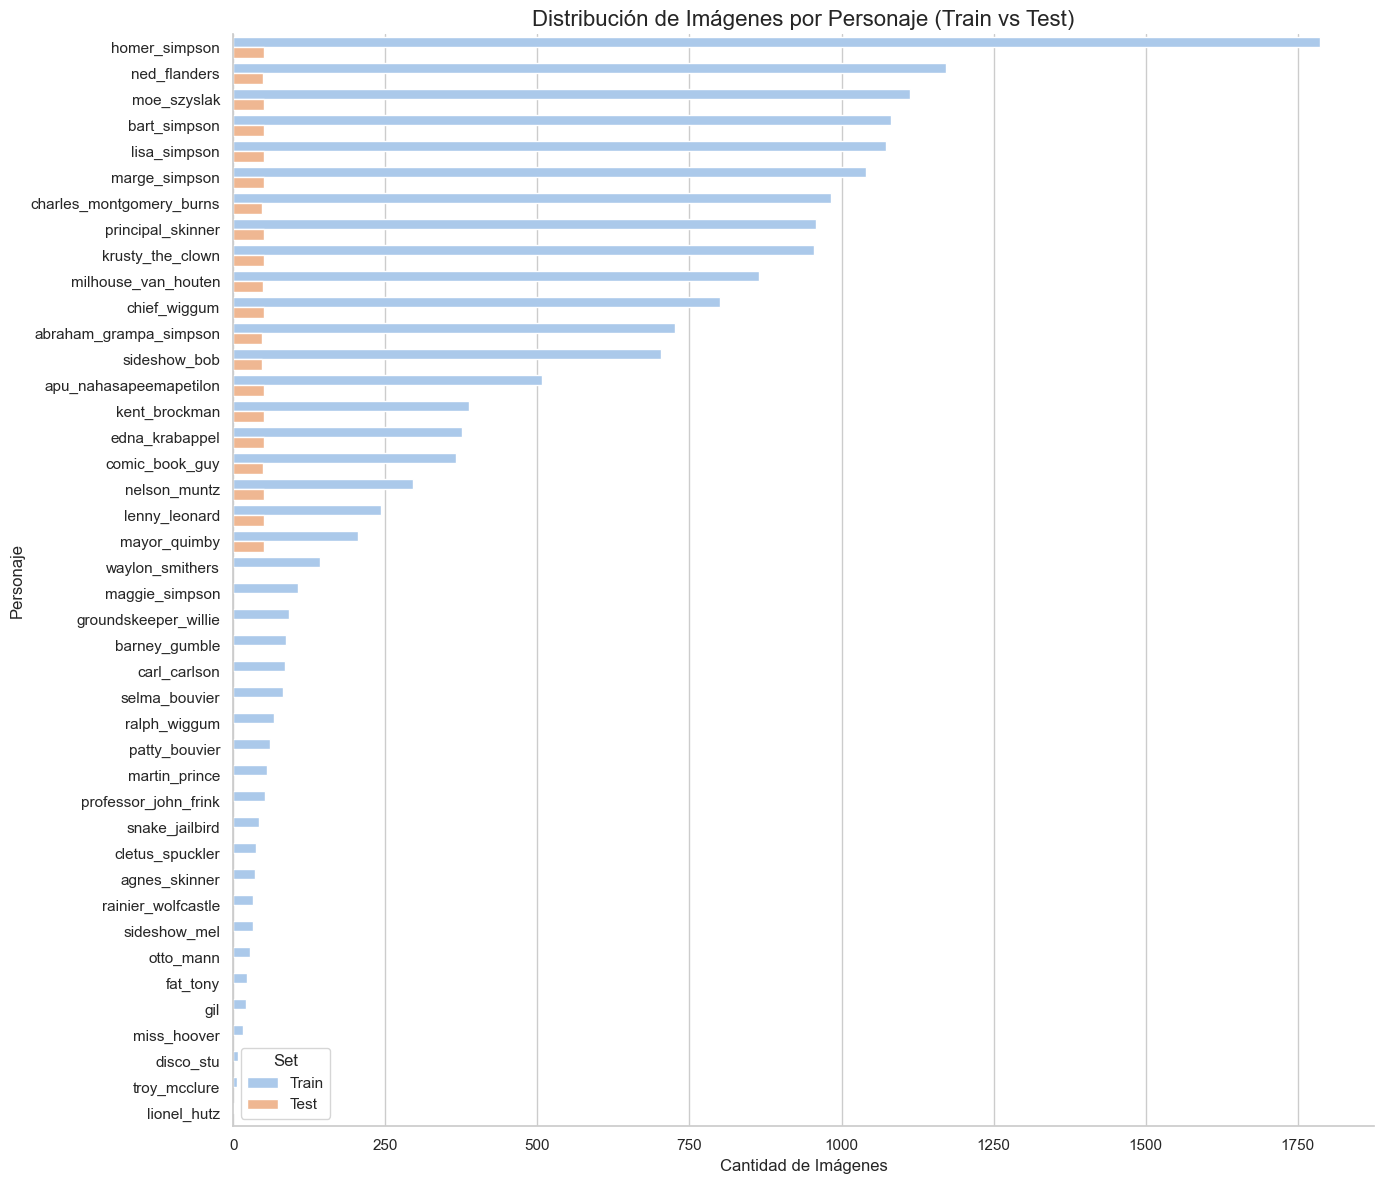

Clases unicas Train: 42
Clases unicas Test: 20


In [ ]:
# Análisis Exploratorio de Datos (EDA) y ETL
train_labels = [label for _, label in datamodule.train_ds.samples]
test_labels = [label for _, label in datamodule.test_ds.samples]

counter_train = collections.Counter(train_labels)
counter_test = collections.Counter(test_labels)

idx_to_class = {v: k for k, v in datamodule.test_ds.class_to_idx.items()}

# Crear DataFrames
df_train = pd.DataFrame([{"Personaje": idx_to_class.get(k, str(k)), "Imágenes": v, "Set": "Train"} for k, v in counter_train.items()])
df_test = pd.DataFrame([{"Personaje": idx_to_class.get(k, str(k)), "Imágenes": v, "Set": "Test"} for k, v in counter_test.items()])

df_dist = pd.concat([df_train, df_test])
# Ordenamos globalmente por la cantidad en el Train
order_keys = df_train.sort_values(by="Imágenes", ascending=False)["Personaje"].tolist()

plt.figure(figsize=(14, 12))
sns.barplot(data=df_dist, x="Imágenes", y="Personaje", hue="Set", palette="pastel", order=order_keys)
plt.title("Distribución de Imágenes por Personaje (Train vs Test)", fontsize=16)
plt.xlabel("Cantidad de Imágenes", fontsize=12)
plt.ylabel("Personaje", fontsize=12)
sns.despine()
plt.tight_layout()
plt.show()

# Análisis de clases presentes y faltantes
train_classes = set(df_train['Personaje'])
test_classes = set(df_test['Personaje'])

print(f"Clases unicas Train: {len(train_classes)}")
print(f"Clases unicas Test: {len(test_classes)}")


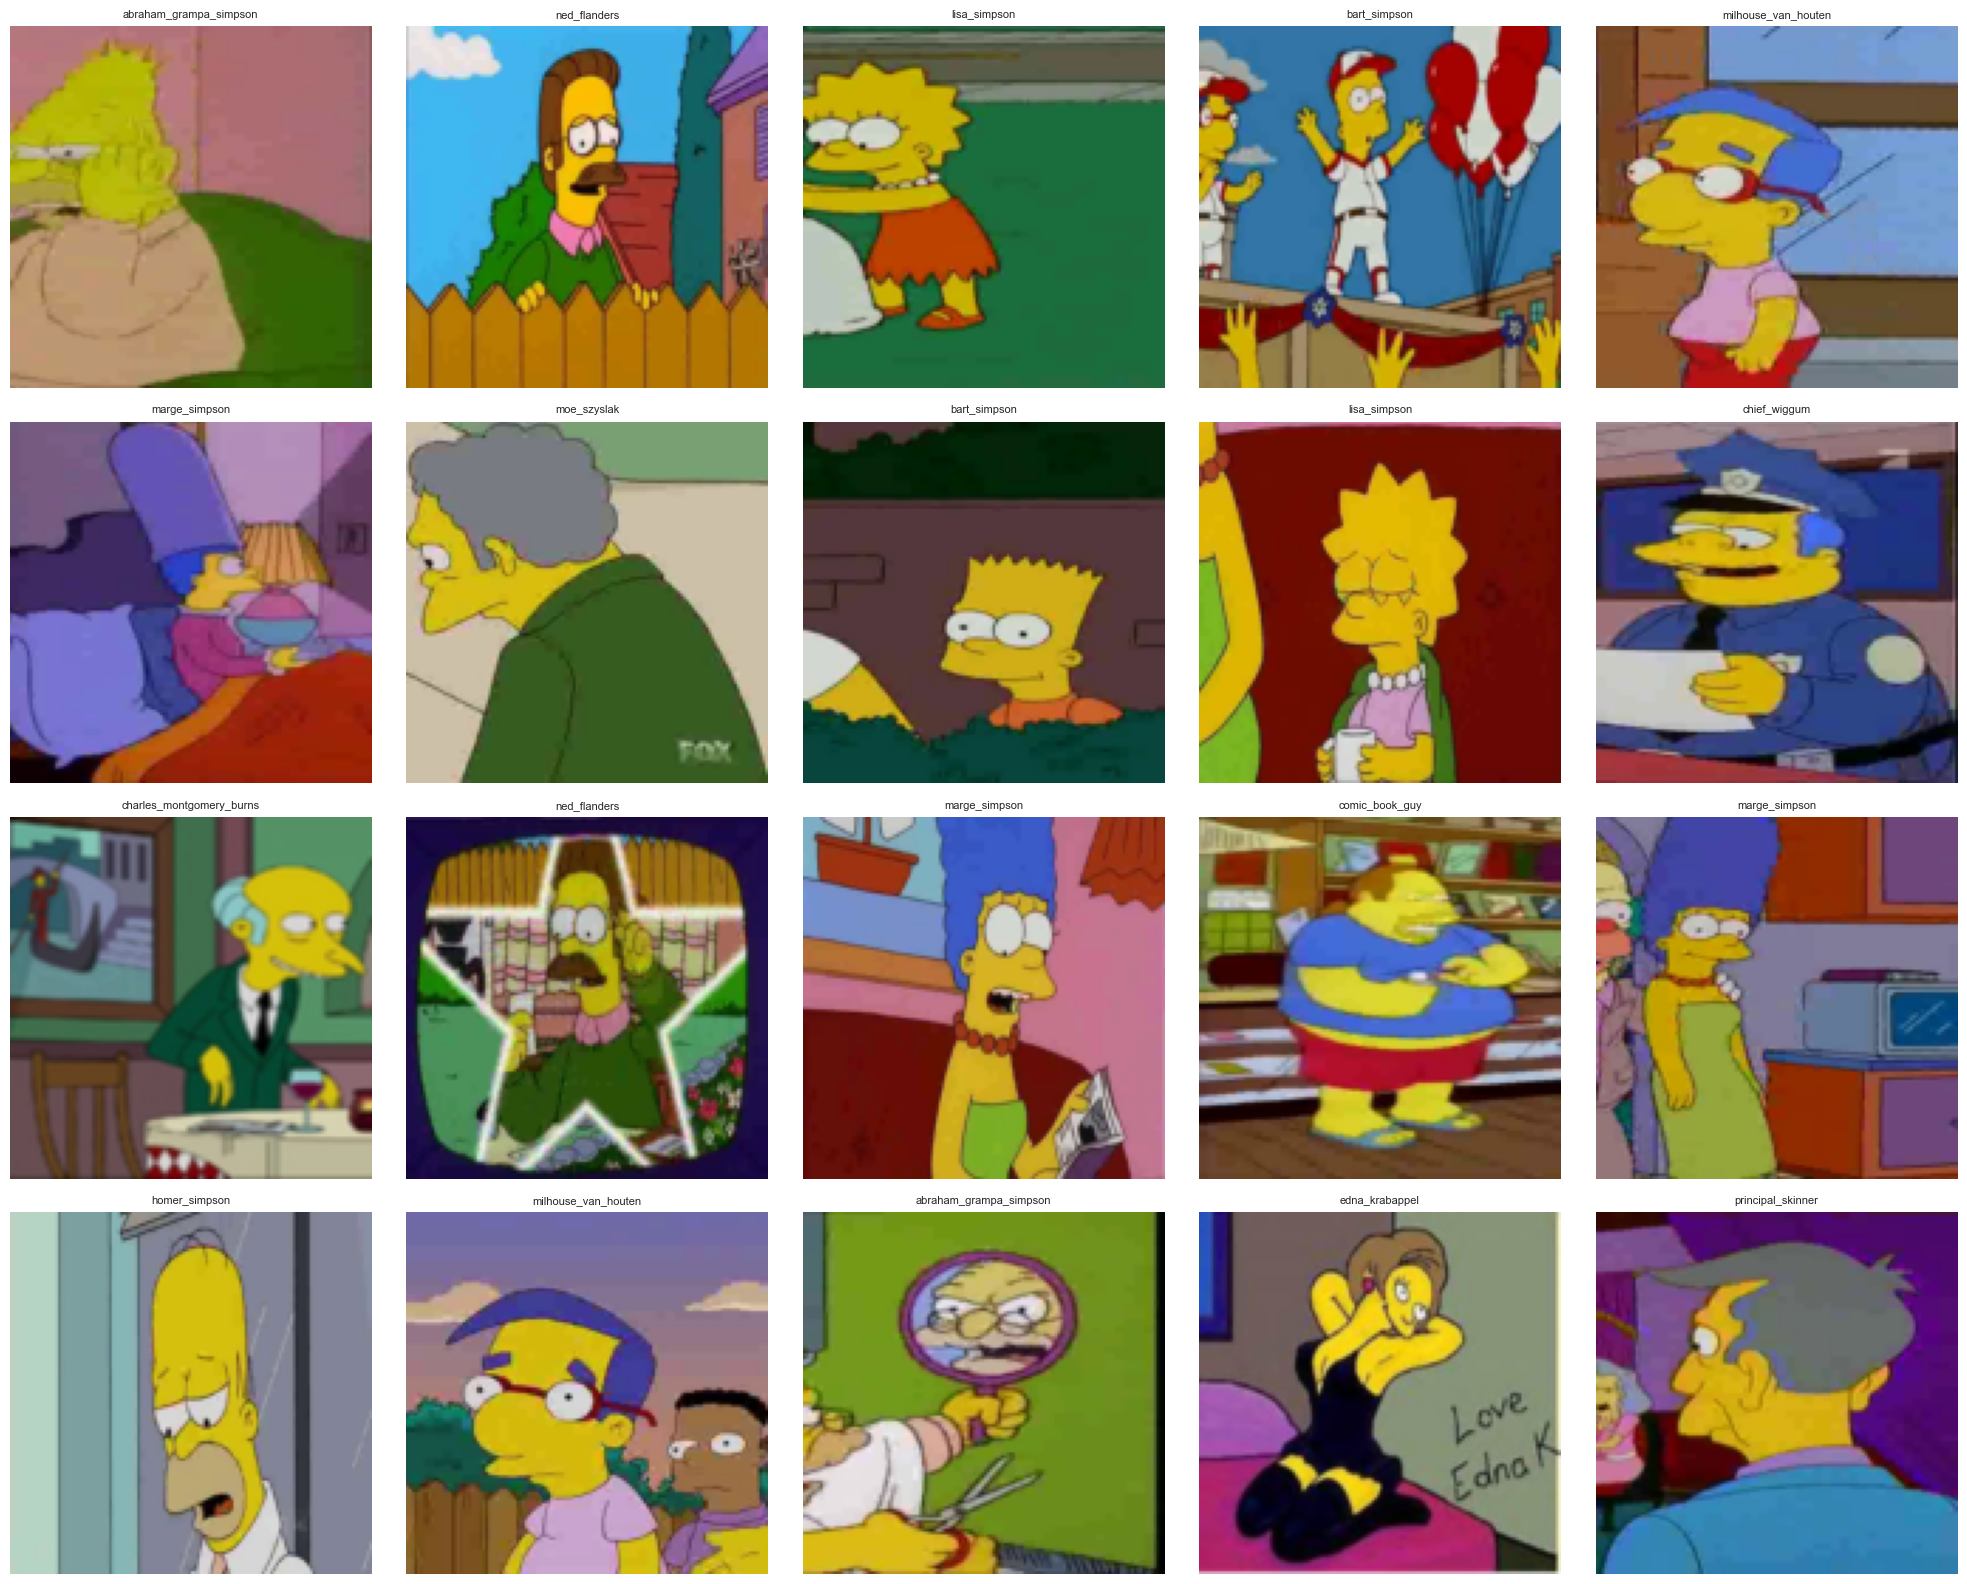

In [22]:
# Visualizar una grilla de imágenes de ejemplo
def imshow(img, title=None):
    # Denormalizar
    img = img.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = std * img + mean
    img = np.clip(img, 0, 1)
    plt.imshow(img)
    if title is not None:
        plt.title(title, fontsize=8)
    plt.axis('off')

train_loader = datamodule.train_dataloader()
images, labels = next(iter(train_loader))

plt.figure(figsize=(20, 16))
for i in range(20):
    plt.subplot(4, 5, i+1)
    imshow(images[i], title=idx_to_class[labels[i].item()])
plt.tight_layout()
plt.show()

## Hallazgos del EDA

**Desbalance de Clases:** Existe una diferencia abismal entre las clases mayoritarias (ej. *Homer Simpson* con miles de imágenes) y las clases minoritarias (ej. *Lionel Hutz* con apenas unas docenas). Esto requiere arquitecturas robustas con capas de Dropout y potencialmente funciones de pérdida ponderadas.

**Carpetas Vacías y Discrepancia de Sets:** Se detectaron carpetas de clases completamente vacías que fueron ignoradas por nuestro cargador de datos personalizado. Además, el Test Set contiene menos clases que el Train Set. Aunque el set de prueba oficial solo contiene a los 20 personajes principales, entrenaremos el modelo usando todas las 42 clases disponibles. Hacer lo contrario provocaría que el modelo pierda capacidad de generalización en el mundo real.

**Scoring:** Dado que el test set carece de 22 clases, usar la métrica `F1-macro` produce un falso sesgo. Si el modelo predice accidentalmente a un personaje que no está en el test set, se le asigna matemáticamente un $0.0$ de F1, castigando drásticamente el promedio macro. Evaluaremos y compararemos los modelos usando `F1-weighted` (promedio ponderado), donde el impacto matemático de cada clase es proporcional a su soporte real, anulando el peso de los personajes faltantes.

## Arquitectura Base
Para comenzar, definimos una arquitectura convolucional simple que nos servirá como línea base.

In [23]:
class CNN1(nn.Module):
    def __init__(self, in_channels: int, num_classes: int):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_channels, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 16 * 16, 512),
            nn.ReLU(),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x))

# Instanciar y ver resumen
cnn1 = CNN1(cfg.in_channels, cfg.num_classes)
summary(cnn1, input_size=(1, 3, cfg.image_size, cfg.image_size))

Layer (type:depth-idx)                   Output Shape              Param #
CNN1                                     [1, 42]                   --
├─Sequential: 1-1                        [1, 128, 16, 16]          --
│    └─Conv2d: 2-1                       [1, 32, 128, 128]         896
│    └─ReLU: 2-2                         [1, 32, 128, 128]         --
│    └─MaxPool2d: 2-3                    [1, 32, 64, 64]           --
│    └─Conv2d: 2-4                       [1, 64, 64, 64]           18,496
│    └─ReLU: 2-5                         [1, 64, 64, 64]           --
│    └─MaxPool2d: 2-6                    [1, 64, 32, 32]           --
│    └─Conv2d: 2-7                       [1, 128, 32, 32]          73,856
│    └─ReLU: 2-8                         [1, 128, 32, 32]          --
│    └─MaxPool2d: 2-9                    [1, 128, 16, 16]          --
├─Sequential: 1-2                        [1, 42]                   --
│    └─Flatten: 2-10                     [1, 32768]                --
│    └

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Loading `train_dataloader` to estimate number of stepping batches.

  | Name           | Type                | Params | Mode  | FLOPs
-----------------------------------------------------------------------
0 | model          | CNN1                | 16.9 M | train | 0    
1 | train_acc      | MulticlassAccuracy  | 0      | train | 0    
2 | val_acc        | MulticlassAccuracy  | 0      | train | 0    
3 | val_f1         | MulticlassF1Score   | 0      | train | 0    
4 | test_acc       | MulticlassAccuracy  | 0      | train | 0    
5 | test_f1        | MulticlassF1Score   | 0      | train | 0    
6 | test_precision | MulticlassPrecision | 0  

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=5` reached.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


\n==================================================\nEvaluando CNN1 (Base)\n==================================================


Testing: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test/acc            0.9585858583450317
    test/f1_weighted         0.95912766456604
        test/loss           0.29988834261894226
     test/precision          0.960900068283081
       test/recall          0.9585858583450317
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


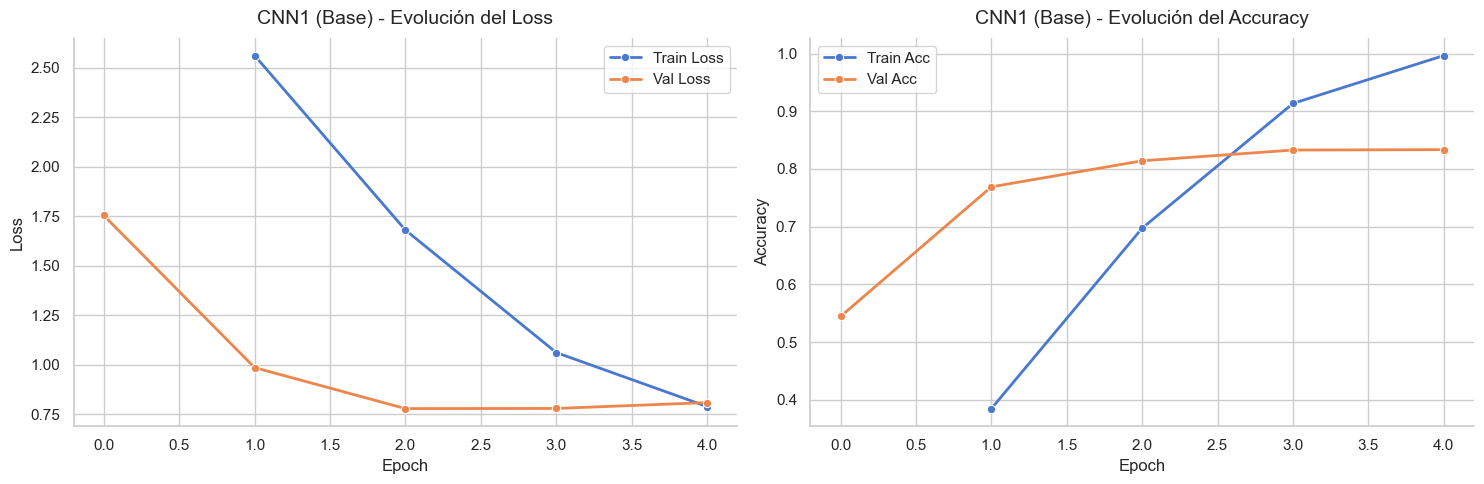

\n--- Reporte de Clasificación ---
                          precision    recall  f1-score   support

  abraham_grampa_simpson       0.92      0.94      0.93        48
  apu_nahasapeemapetilon       0.96      1.00      0.98        50
            bart_simpson       0.94      0.98      0.96        50
charles_montgomery_burns       0.94      0.94      0.94        48
            chief_wiggum       0.94      0.98      0.96        50
          comic_book_guy       1.00      0.92      0.96        49
          edna_krabappel       0.96      0.98      0.97        50
           homer_simpson       0.85      0.94      0.90        50
           kent_brockman       0.96      0.98      0.97        50
        krusty_the_clown       1.00      1.00      1.00        50
           lenny_leonard       1.00      0.86      0.92        50
            lisa_simpson       0.96      0.94      0.95        50
           marge_simpson       1.00      0.96      0.98        50
            mayor_quimby       1.00     

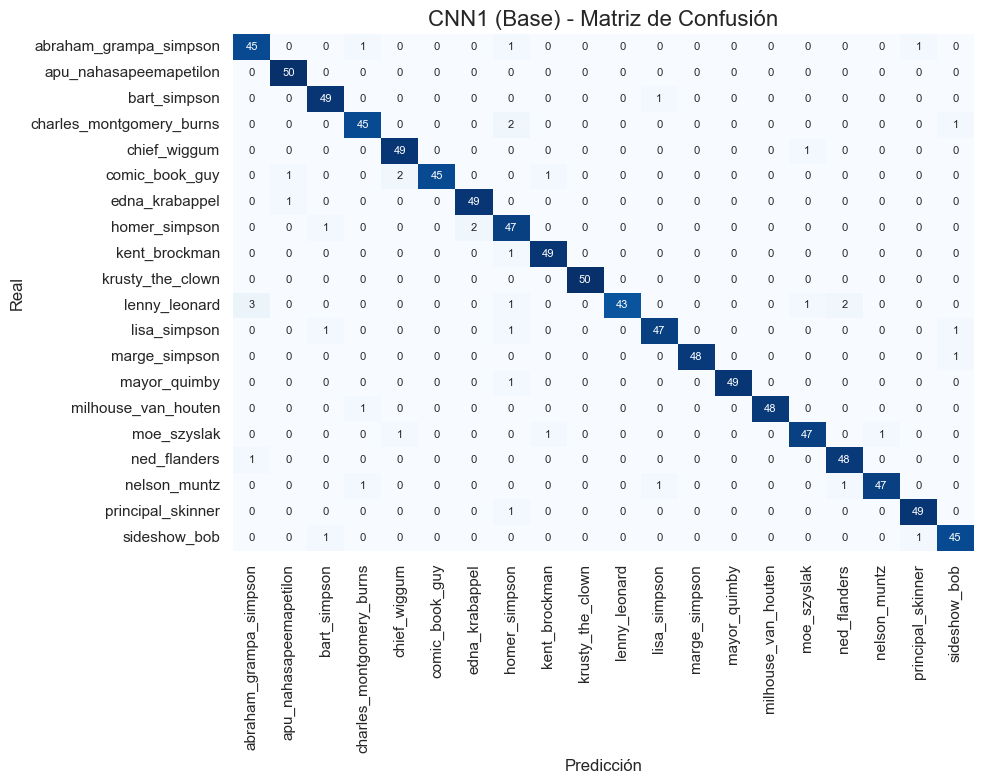

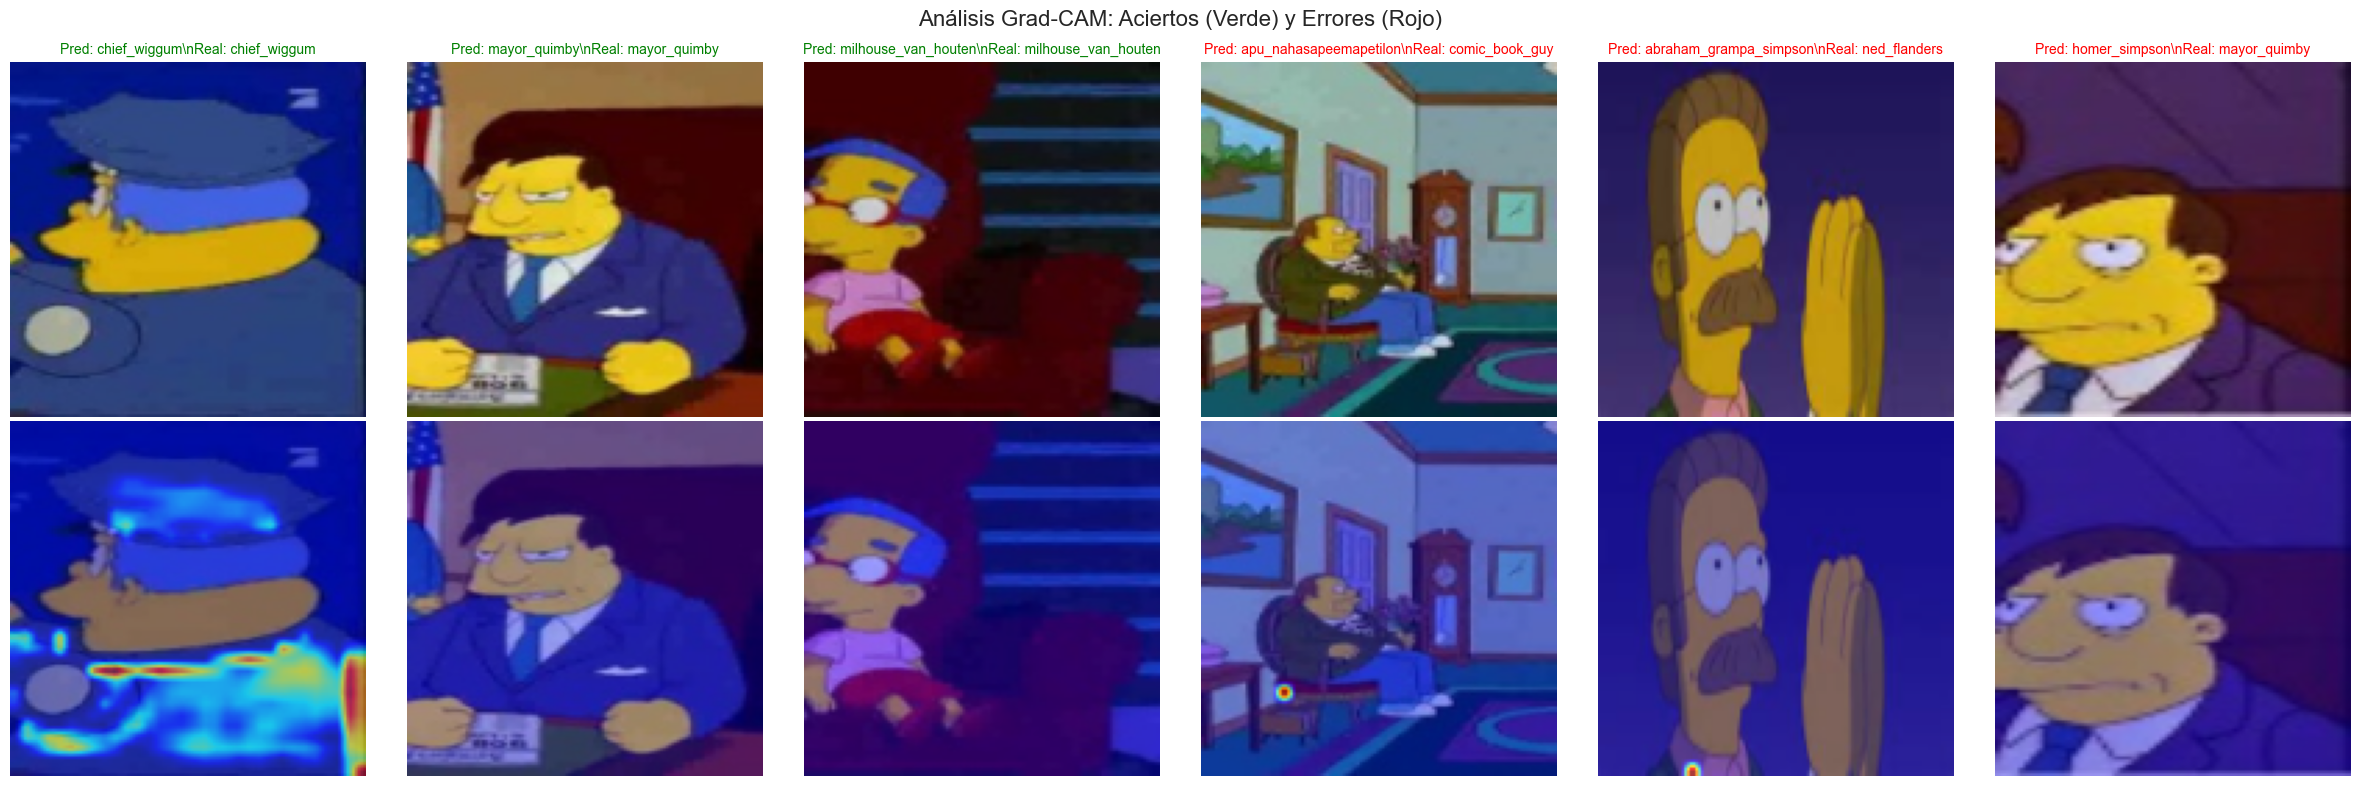

In [24]:
# Entrenamiento CNN1
model_1 = SimpsonsModule(cfg, model=CNN1(cfg.in_channels, cfg.num_classes))

history_1 = MemoryHistoryCallback()

trainer_1 = L.Trainer(
    max_epochs=cfg.max_epochs,
    accelerator="auto",
    logger=False,
    callbacks=[history_1],
    deterministic=True,
    enable_checkpointing=False
)

trainer_1.fit(model_1, datamodule=datamodule)

from src.visualization import evaluate_model
evaluate_model(model_1, trainer_1, datamodule, history_1.history, target_layer=model_1.model.features[6], title='CNN1 (Base)')


## Evaluación 

In [25]:
# Creación de Tabla Comparativa
results_dict = {
    "CNN1 (Base)": res_cnn1[0],
}

df_results = pd.DataFrame(results_dict).T
# Filtramos solo las métricas clave para claridad
cols_to_show = ["test/loss", "test/acc", "test/f1_weighted", "test/precision", "test/recall"]
df_results = df_results[cols_to_show]
df_results

,test/loss,test/acc,test/f1_weighted,test/precision,test/recall
CNN1 (Base),0.283413,0.966667,0.96716,0.968732,0.966667


## Conclusiones